Loaded data shape: (121, 7)
Training stacked ensemble...

Model performance on test set:
R²: 0.7734  |  RMSE: 24.5181  |  MAE: 15.7062
Saved artefacts to: vegetable_price_stack.pkl


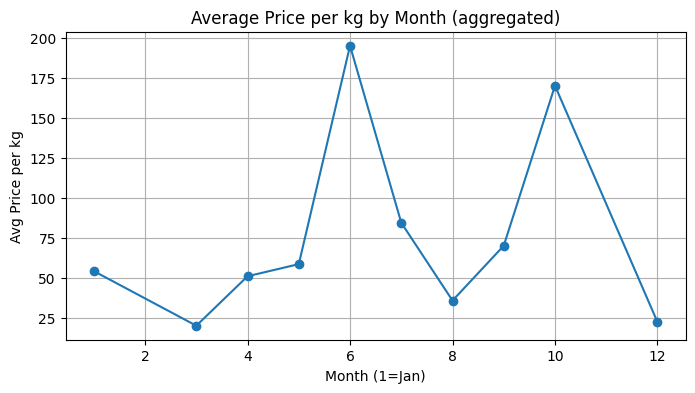


Enter details for prediction (type 'exit' to cancel):

===== Prediction Summary =====
Inputs:
Vegetable Season Month Temp Deasaster Happen in last 3month Vegetable condition
    onion summer  june   30                              no               fresh

Outputs:
Predicted Price per kg: ₹25.46
Estimated Demand (units): 198.18
Logistics Advice: Use cold-chain / refrigerated transport and faster routes to retain freshness.
Crop Recommendation: High demand — consider planting more of this crop next cycle (or increasing harvest).

Prediction session ended.


In [1]:
# vegetable_price_pipeline.py
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Tuple, Dict, Any, List

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
N_JOBS = -1
DEFAULT_SAVE = "vegetable_price_stack.pkl"

MONTH_MAP = {
    'jan': 1, 'january': 1,
    'feb': 2, 'february': 2,
    'mar': 3, 'march': 3,
    'apr': 4, 'april': 4,
    'may': 5,
    'jun': 6, 'june': 6,
    'jul': 7, 'july': 7,
    'aug': 8, 'august': 8,
    'sep': 9, 'sept': 9, 'september': 9,
    'oct': 10, 'october': 10,
    'nov': 11, 'november': 11,
    'dec': 12, 'december': 12
}

# -------------------------
# Cleaning / Preprocessing
# -------------------------
def clean_and_prepare_df(df: pd.DataFrame, training: bool = True) -> pd.DataFrame:
    """
    Clean DataFrame. If training=True, requires & converts 'Price per kg'.
    If training=False, it will skip checks for price column (for single-row input during prediction).
    """
    df = df.copy()
    # normalize column names & strip whitespace from string values
    df.columns = [c.strip() for c in df.columns]

    # Trim strings & replace common missing tokens
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].astype(str).str.strip().replace({'': np.nan, 'nan': np.nan, 'None': np.nan, 'NA': np.nan})

    # Fix common typos & lower-case for mapping use
    if 'Vegetable condition' in df.columns:
        df['Vegetable condition'] = df['Vegetable condition'].str.replace('scarp', 'scrap', regex=False)

    if 'Deasaster Happen in last 3month' in df.columns:
        df['Deasaster Happen in last 3month'] = (
            df['Deasaster Happen in last 3month'].astype(str).str.lower()
        )

    if 'Month' in df.columns:
        df['Month'] = df['Month'].astype(str).str.strip().str.lower()

    if training:
        if 'Price per kg' not in df.columns:
            raise ValueError("Dataset must contain 'Price per kg' column in training mode")
        # ensure numeric target
        df['Price per kg'] = pd.to_numeric(df['Price per kg'], errors='coerce')

    # Try numeric coercion for Temp
    if 'Temp' in df.columns:
        df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

    # For numeric cols, fill NA with mean (training) or sensible defaults (prediction)
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isna().any():
            if training:
                df[col] = df[col].fillna(df[col].mean())
            else:
                df[col] = df[col].fillna(0)

    return df

def preprocess_inputs(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, StandardScaler, List[str], List[str]]:
    """
    Full preprocessing pipeline for training:
    - clean
    - map month
    - map disaster
    - one-hot encode categorical columns (Vegetable, Season, Vegetable condition)
    - train/test split
    - scale numeric columns
    Returns X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_columns, numeric_columns
    """
    df = clean_and_prepare_df(df, training=True)

    # Binary disaster
    if 'Deasaster Happen in last 3month' in df.columns:
        df['Deasaster Happen in last 3month'] = df['Deasaster Happen in last 3month'].replace({'no': 0, 'yes': 1, 'n': 0, 'y': 1})
        df['Deasaster Happen in last 3month'] = df['Deasaster Happen in last 3month'].fillna(0).astype(int)

    # Map month to ordinal
    if 'Month' in df.columns:
        df['Month'] = df['Month'].map(MONTH_MAP)
        if df['Month'].isna().any():
            df['Month'] = df['Month'].fillna(df['Month'].mode()[0] if not df['Month'].mode().empty else 1)

    # Fill remaining numeric NA's (if any)
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(df[col].mean())

    # One-hot encode categorical columns
    categorical_cols = [c for c in ['Vegetable', 'Season', 'Vegetable condition'] if c in df.columns]
    if categorical_cols:
        df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=False)  # Changed to drop_first=False for better prediction alignment
    else:
        df_enc = df.copy()

    # Separate X and y
    y = df_enc['Price per kg']
    X = df_enc.drop('Price per kg', axis=1)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=SEED, shuffle=True)

    # Numeric columns for scaling
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    if numeric_cols:
        X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    feature_columns = list(X.columns)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_columns, numeric_cols

# -------------------------
# Model builders / trainers
# -------------------------
def build_stacked_model(do_tune: bool = False, random_state: int = SEED, n_jobs: int = N_JOBS):
    # base learners
    xgb = XGBRegressor(n_estimators=200, learning_rate=0.08, max_depth=4, random_state=random_state, n_jobs=n_jobs, verbosity=0)
    lgbm = LGBMRegressor(n_estimators=200, learning_rate=0.08, max_depth=6, random_state=random_state, n_jobs=n_jobs)
    cat = CatBoostRegressor(iterations=200, learning_rate=0.08, depth=4, verbose=0, random_state=random_state)

    if do_tune:
        # light tuning spaces
        xgb_param = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.08], 'max_depth': [3, 4]}
        lgbm_param = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.08], 'max_depth': [3, 6]}
        cat_param = {'iterations': [100, 200], 'learning_rate': [0.05, 0.08], 'depth': [3, 4]}

        xgb = RandomizedSearchCV(XGBRegressor(random_state=random_state, n_jobs=n_jobs, verbosity=0),
                                 xgb_param, n_iter=3, cv=3, random_state=random_state, n_jobs=1, verbose=0)
        lgbm = RandomizedSearchCV(LGBMRegressor(random_state=random_state, n_jobs=n_jobs),
                                  lgbm_param, n_iter=3, cv=3, random_state=random_state, n_jobs=1, verbose=0)
        cat = RandomizedSearchCV(CatBoostRegressor(random_state=random_state, verbose=0),
                                 cat_param, n_iter=3, cv=3, random_state=random_state, n_jobs=1, verbose=0)

    stack = StackingRegressor(
        estimators=[('xgb', xgb), ('lgbm', lgbm), ('cat', cat)],
        final_estimator=Ridge(alpha=1.0),
        n_jobs=n_jobs,
        passthrough=False
    )
    return stack

def train_and_evaluate(df: pd.DataFrame, do_tune: bool = False, save_path: str = DEFAULT_SAVE) -> Tuple[Dict[str, Any], Tuple[float, float, float]]:
    # Preprocess
    X_train, X_test, y_train, y_test, scaler, feature_columns, numeric_cols = preprocess_inputs(df)

    model = build_stacked_model(do_tune=do_tune)
    print("Training stacked ensemble...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_test_arr = np.asarray(y_test)
    y_pred_arr = np.asarray(y_pred)

    r2 = r2_score(y_test_arr, y_pred_arr)
    mse = mean_squared_error(y_test_arr, y_pred_arr)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_arr, y_pred_arr)

    print("\nModel performance on test set:")
    print(f"R²: {r2:.4f}  |  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}")

    artefacts = {
        'model': model,
        'scaler': scaler,
        'feature_columns': feature_columns,
        'numeric_cols': numeric_cols
    }
    joblib.dump(artefacts, save_path)
    print(f"Saved artefacts to: {save_path}")

    return artefacts, (r2, rmse, mae)

# -------------------------
# Prediction helpers
# -------------------------
def load_pipeline(pickle_path: str = DEFAULT_SAVE):
    artefacts = joblib.load(pickle_path)
    return artefacts['model'], artefacts['scaler'], artefacts['feature_columns'], artefacts.get('numeric_cols', [])

def simulate_demand(price: float, baseline_demand: float = 100, elasticity: float = 0.5) -> float:
    price = float(price)
    return baseline_demand * (price / baseline_demand) ** (-elasticity)

def logistics_advice(season: str, condition: str) -> str:
    season = str(season).strip().lower()
    condition = str(condition).strip().lower()
    if condition in ['scrap', 'scrp', 'scraped', 'damaged']:
        return "Recommend local sale or processing (low transport value)."
    if season in ['summer', 'monsoon', 'rainy']:
        return "Use cold-chain / refrigerated transport and faster routes to retain freshness."
    return "Standard transport with good packaging; prioritize high-demand markets."

def crop_recommendation(predicted_demand: float, threshold_high: float = 100, threshold_low: float = 60) -> str:
    if predicted_demand >= threshold_high:
        return "High demand — consider planting more of this crop next cycle (or increasing harvest)."
    elif predicted_demand <= threshold_low:
        return "Low demand — consider diversifying to other crops or storing."
    return "Moderate demand — maintain current planting levels."

def predict_price_interactive(model, scaler, feature_columns: List[str], numeric_cols: List[str], baseline_demand: int = 100):
    print("\nEnter details for prediction (type 'exit' to cancel):")
    Vegetable = input("Vegetable: ").strip()
    if Vegetable.lower() == 'exit': return
    Season = input("Season: ").strip()
    if Season.lower() == 'exit': return
    Month_raw = input("Month (e.g. 'june'): ").strip()
    if Month_raw.lower() == 'exit': return
    Temp_raw = input("Temperature (numeric): ").strip()
    if Temp_raw.lower() == 'exit': return
    Disaster_raw = input("Disaster in last 3 months (yes/no): ").strip()
    if Disaster_raw.lower() == 'exit': return
    Condition = input("Condition (fresh/scrap): ").strip()
    if Condition.lower() == 'exit': return

    # Create DataFrame with original values (for display)
    user_df_original = pd.DataFrame({
        'Vegetable': [Vegetable],
        'Season': [Season],
        'Month': [Month_raw],
        'Temp': [Temp_raw],
        'Deasaster Happen in last 3month': [Disaster_raw],
        'Vegetable condition': [Condition]
    })

    # Create working copy for processing
    user_df = user_df_original.copy()

    # Clean (prediction mode)
    user_df = clean_and_prepare_df(user_df, training=False)

    # Map month & disaster
    user_df['Month'] = user_df['Month'].map(MONTH_MAP).fillna(1)
    user_df['Deasaster Happen in last 3month'] = (
        user_df['Deasaster Happen in last 3month']
        .str.lower()
        .replace({'no': 0, 'yes': 1, 'n': 0, 'y': 1})
        .fillna(0)
        .astype(int)
    )
    user_df['Vegetable condition'] = user_df['Vegetable condition'].fillna('fresh')
    user_df['Temp'] = pd.to_numeric(user_df['Temp'], errors='coerce').fillna(0)

    # One-hot encode user input
    cat_cols = [c for c in ['Vegetable', 'Season', 'Vegetable condition'] if c in user_df.columns]
    
    # Create all possible dummy columns first
    user_enc = pd.get_dummies(user_df, columns=cat_cols, drop_first=False)
    
    # Now ensure we have all columns that were in training
    for col in feature_columns:
        if col not in user_enc.columns:
            # Add missing columns with 0 values
            user_enc[col] = 0
    
    # Reorder columns to exactly match training data
    user_enc = user_enc[feature_columns]

    # Scale numeric columns
    if numeric_cols:
        user_enc[numeric_cols] = scaler.transform(user_enc[numeric_cols])

    # Predict
    pred_price = float(model.predict(user_enc)[0])
    pred_demand = simulate_demand(pred_price, baseline_demand=baseline_demand)
    logistics = logistics_advice(Season, Condition)
    recommendation = crop_recommendation(pred_demand)
    
    print("\n===== Prediction Summary =====")
    print("Inputs:")
    print(user_df_original.to_string(index=False))
    print("\nOutputs:")
    print(f"Predicted Price per kg: ₹{pred_price:.2f}")
    print(f"Estimated Demand (units): {pred_demand:.2f}")
    print(f"Logistics Advice: {logistics}")
    print(f"Crop Recommendation: {recommendation}")
    print("==============================")

    return {
        'price': pred_price, 
        'demand': pred_demand, 
        'logistics': logistics, 
        'recommendation': recommendation
    }

# -------------------------
# Visualization
# -------------------------
def plot_monthly_trends(df: pd.DataFrame):
    df = df.copy()
    df['Month_norm'] = df['Month'].astype(str).str.strip().str.lower().map(MONTH_MAP)
    if df['Month_norm'].isna().all():
        print("No valid month data to plot.")
        return
    monthly = df.groupby('Month_norm')['Price per kg'].mean().sort_index()
    plt.figure(figsize=(8, 4))
    monthly.plot(marker='o')
    plt.title('Average Price per kg by Month (aggregated)')
    plt.xlabel('Month (1=Jan)')
    plt.ylabel('Avg Price per kg')
    plt.grid(True)
    plt.show()

# -------------------------
# CLI / Main
# -------------------------
if __name__ == "__main__":
    csv_path = Path("Vegetable_market.csv")
    if not csv_path.exists():
        print("Place 'Vegetable_market.csv' in working directory or call train_and_evaluate(df) from code.")
    else:
        df = pd.read_csv(csv_path)
        print("Loaded data shape:", df.shape)

        artefacts, metrics = train_and_evaluate(df, do_tune=False, save_path=DEFAULT_SAVE)
        model, scaler, feature_columns, numeric_cols = artefacts['model'], artefacts['scaler'], artefacts['feature_columns'], artefacts['numeric_cols']

        # Plot trends
        plot_monthly_trends(df)

        # Interactive prediction loop
        while True:
            try:
                result = predict_price_interactive(model, scaler, feature_columns, numeric_cols)
                if result is None:  # User typed 'exit'
                    break
                cont = input("\nMake another prediction? (y/n): ").strip().lower()
                if cont != 'y':
                    break
            except Exception as e:
                print(f"Error during prediction: {str(e)}")
                print("Please try again with valid inputs.")
                continue

        print("\nPrediction session ended.")